<a href="https://colab.research.google.com/github/siqueirago/BairesDev-Machine-Learning-Practitioner/blob/main/Matrix_confusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [6]:
tf.__version__

'2.18.0'

In [7]:
%load_ext tensorboard

In [8]:
logdir = 'log'

In [10]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

train_images, test_images = train_images / 255.0, test_images / 255.0

classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [12]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))



In [13]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

In [15]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 34ms/step - accuracy: 0.9940 - loss: 0.0184 - val_accuracy: 0.9910 - val_loss: 0.0303
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.9960 - loss: 0.0119 - val_accuracy: 0.9917 - val_loss: 0.0329
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.9961 - loss: 0.0118 - val_accuracy: 0.9919 - val_loss: 0.0300
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.9972 - loss: 0.0081 - val_accuracy: 0.9913 - val_loss: 0.0400
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9974 - loss: 0.0090 - val_accuracy: 0.9910 - val_loss: 0.0416


In [18]:

y_true = test_labels
y_pred = np.argmax(model.predict(test_images), axis=-1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [19]:
classes = [0, 1, 2, 3, 4, 5 ,6, 7, 8, 9]

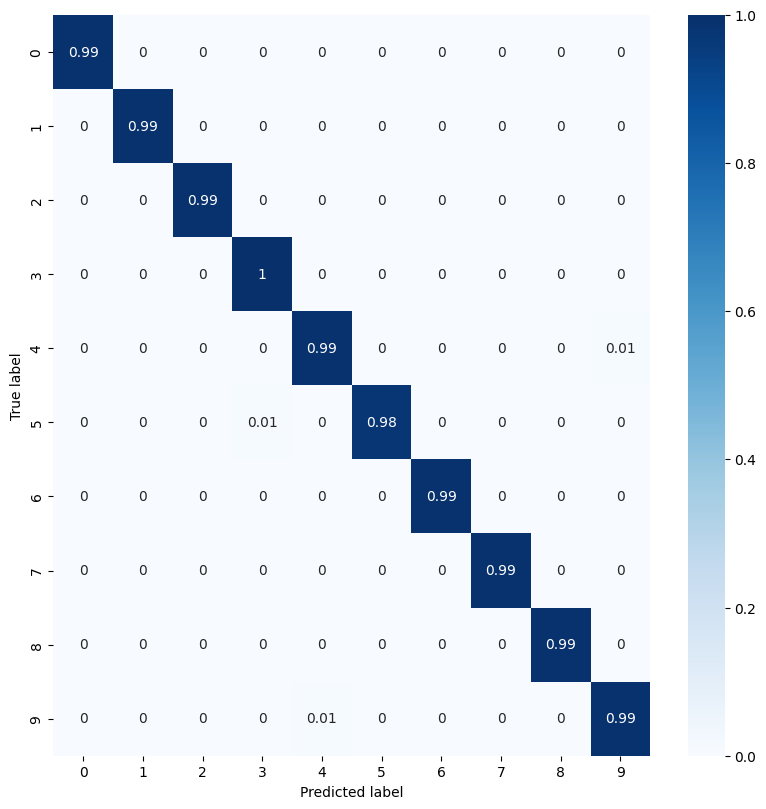

In [20]:
con_mat = tf.math.confusion_matrix(labels=y_true, predictions=y_pred).numpy()
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

con_mat_df = pd.DataFrame(con_mat_norm,
                     index = classes,
                     columns = classes)

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot=True,cmap=plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')

plt.show()

In [ ]:
cm = confusion_matrix(y_true, y_pred)

In [24]:
accuracy = accuracy_score(y_true, y_pred)
print(accuracy)

0.991


In [27]:
# Calcualando a sensibilidade para cada classe
from sklearn.metrics import confusion_matrix, recall_score
cm = confusion_matrix(y_true, y_pred)


In [28]:
sensibilidade_por_classe = recall_score(y_true, y_pred, average=None)
for i, sensibilidade in enumerate(sensibilidade_por_classe):

 print(f"Sensibilidade para a classe {i}: {sensibilidade}")

Sensibilidade para a classe 0: 0.9948979591836735
Sensibilidade para a classe 1: 0.9938325991189427
Sensibilidade para a classe 2: 0.9932170542635659
Sensibilidade para a classe 3: 0.996039603960396
Sensibilidade para a classe 4: 0.9887983706720977
Sensibilidade para a classe 5: 0.9809417040358744
Sensibilidade para a classe 6: 0.9906054279749478
Sensibilidade para a classe 7: 0.9902723735408561
Sensibilidade para a classe 8: 0.9938398357289527
Sensibilidade para a classe 9: 0.9861248761149654


In [30]:
# Calculando a sensibilidade média
sensibilidade_media = recall_score(y_true, y_pred, average='macro')

print(f"Sensibilidade média: {sensibilidade_media}")

Sensibilidade média: 0.9908569804594272


In [31]:
# Calculando a Especificidade por classe
especificidade_por_classe = []
for i in range(len(cm)):

  TN = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))  # Verdadeiros Negativos
  FP = np.sum(cm[:, i]) - cm[i, i]  # Falsos Positivos
  especificidade = TN / (TN + FP)
  especificidade_por_classe.append(especificidade)
  print(f"Especificidade para a classe {i}: {especificidade}")

Especificidade para a classe 0: 0.9996674057649667
Especificidade para a classe 1: 0.9989847715736041
Especificidade para a classe 2: 0.9989964317573595
Especificidade para a classe 3: 0.9981090100111235
Especificidade para a classe 4: 0.999001996007984
Especificidade para a classe 5: 0.9995608256477821
Especificidade para a classe 6: 0.9994470249944702
Especificidade para a classe 7: 0.9985510477039679
Especificidade para a classe 8: 0.9991136716153335
Especificidade para a classe 9: 0.9985541096652207


In [32]:
# Especificidade média por classe
especificidade_media = np.mean(especificidade_por_classe)
print(f"Especificidade média: {especificidade_media}")

Especificidade média: 0.9989986294741813


In [33]:
# Precisão para cada class
from sklearn.metrics import precision_score

precisao_por_classe = precision_score(y_true, y_pred, average=None)
for i, precisao in enumerate(precisao_por_classe):
 print(f"Precisão para a classe {i}: {precisao}")

Precisão para a classe 0: 0.9969325153374233
Precisão para a classe 1: 0.9920844327176781
Precisão para a classe 2: 0.9912959381044487
Precisão para a classe 3: 0.9833822091886608
Precisão para a classe 4: 0.9908163265306122
Precisão para a classe 5: 0.9954493742889647
Precisão para a classe 6: 0.9947589098532494
Precisão para a classe 7: 0.9873908826382153
Precisão para a classe 8: 0.9918032786885246
Precisão para a classe 9: 0.9871031746031746


In [35]:
# Precisão média
precisao_media = precision_score(y_true, y_pred, average='macro')  # ou 'weighted'
print(f"Precisão média: {precisao_media}")


Precisão média: 0.991101704195095


In [36]:
# Calcular o F-score para cada classe

f1_por_classe = f1_score(y_true, y_pred, average=None)
for i, f1 in enumerate(f1_por_classe):
  print(f"F-score para a classe {i}: {f1}")


F-score para a classe 0: 0.9959141981613892
F-score para a classe 1: 0.9929577464788732
F-score para a classe 2: 0.9922555663117134
F-score para a classe 3: 0.9896704377766847
F-score para a classe 4: 0.9898063200815495
F-score para a classe 5: 0.9881422924901185
F-score para a classe 6: 0.9926778242677824
F-score para a classe 7: 0.9888295288975231
F-score para a classe 8: 0.9928205128205129
F-score para a classe 9: 0.9866137828458106


In [37]:
# F-score médio
f1_media = f1_score(y_true, y_pred, average='macro')  # ou 'weighted'
print(f"F-score médio: {f1_media}")


F-score médio: 0.9909688210131957
